In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('heart.csv')

In [3]:
def classify_risk(row):
    if row["target"] == 0:
        return 0
    elif row["target"] == 1 and row["oldpeak"] < 2:
        return 1
    else:
        return 2

data["risk_level"] = data.apply(classify_risk, axis=1)
data.drop(columns=["target"], inplace=True)

print(data["risk_level"].value_counts())

data.to_csv("heart_multiclass.csv", index=False)


risk_level
0    499
1    498
2     28
Name: count, dtype: int64


In [4]:
data.shape

(1025, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1025 non-null   int64  
 1   sex         1025 non-null   int64  
 2   cp          1025 non-null   int64  
 3   trestbps    1025 non-null   int64  
 4   chol        1025 non-null   int64  
 5   fbs         1025 non-null   int64  
 6   restecg     1025 non-null   int64  
 7   thalach     1025 non-null   int64  
 8   exang       1025 non-null   int64  
 9   oldpeak     1025 non-null   float64
 10  slope       1025 non-null   int64  
 11  ca          1025 non-null   int64  
 12  thal        1025 non-null   int64  
 13  risk_level  1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,risk_level
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'risk_level'],
      dtype='object')

In [8]:
print(data.dtypes)

age             int64
sex             int64
cp              int64
trestbps        int64
chol            int64
fbs             int64
restecg         int64
thalach         int64
exang           int64
oldpeak       float64
slope           int64
ca              int64
thal            int64
risk_level      int64
dtype: object


In [9]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,risk_level
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.540488
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.550718
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,2.000000


In [10]:
missing=data.isnull()
print(missing)

        age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0     False  False  False     False  False  False    False    False  False   
1     False  False  False     False  False  False    False    False  False   
2     False  False  False     False  False  False    False    False  False   
3     False  False  False     False  False  False    False    False  False   
4     False  False  False     False  False  False    False    False  False   
...     ...    ...    ...       ...    ...    ...      ...      ...    ...   
1020  False  False  False     False  False  False    False    False  False   
1021  False  False  False     False  False  False    False    False  False   
1022  False  False  False     False  False  False    False    False  False   
1023  False  False  False     False  False  False    False    False  False   
1024  False  False  False     False  False  False    False    False  False   

      oldpeak  slope     ca   thal  risk_level  
0       False 

In [11]:
print(data.isnull().sum())

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
risk_level    0
dtype: int64


In [12]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [13]:
print(data.duplicated().sum())

723


In [14]:
data = data.drop_duplicates()
print(data.duplicated().sum())

0


In [15]:
remaining_rows = data.shape[0]
print("Remaining rows:", remaining_rows)

Remaining rows: 302


In [16]:
print(data["risk_level"].value_counts())

risk_level
1    155
0    138
2      9
Name: count, dtype: int64


                 age       sex        cp  trestbps      chol       fbs  \
age         1.000000 -0.094962 -0.063107  0.283121  0.207216  0.119492   
sex        -0.094962  1.000000 -0.051740 -0.057647 -0.195571  0.046022   
cp         -0.063107 -0.051740  1.000000  0.046486 -0.072682  0.096018   
trestbps    0.283121 -0.057647  0.046486  1.000000  0.125256  0.178125   
chol        0.207216 -0.195571 -0.072682  0.125256  1.000000  0.011428   
fbs         0.119492  0.046022  0.096018  0.178125  0.011428  1.000000   
restecg    -0.111590 -0.060351  0.041561 -0.115367 -0.147602 -0.083081   
thalach    -0.395235 -0.046439  0.293367 -0.048023 -0.005308 -0.007169   
exang       0.093216  0.143460 -0.392937  0.068526  0.064099  0.024729   
oldpeak     0.206040  0.098322 -0.146692  0.194600  0.050086  0.004514   
slope      -0.164124 -0.032990  0.116854 -0.122873  0.000417 -0.058654   
ca          0.302261  0.113060 -0.195356  0.099248  0.086878  0.144935   
thal        0.065317  0.211452 -0.1603

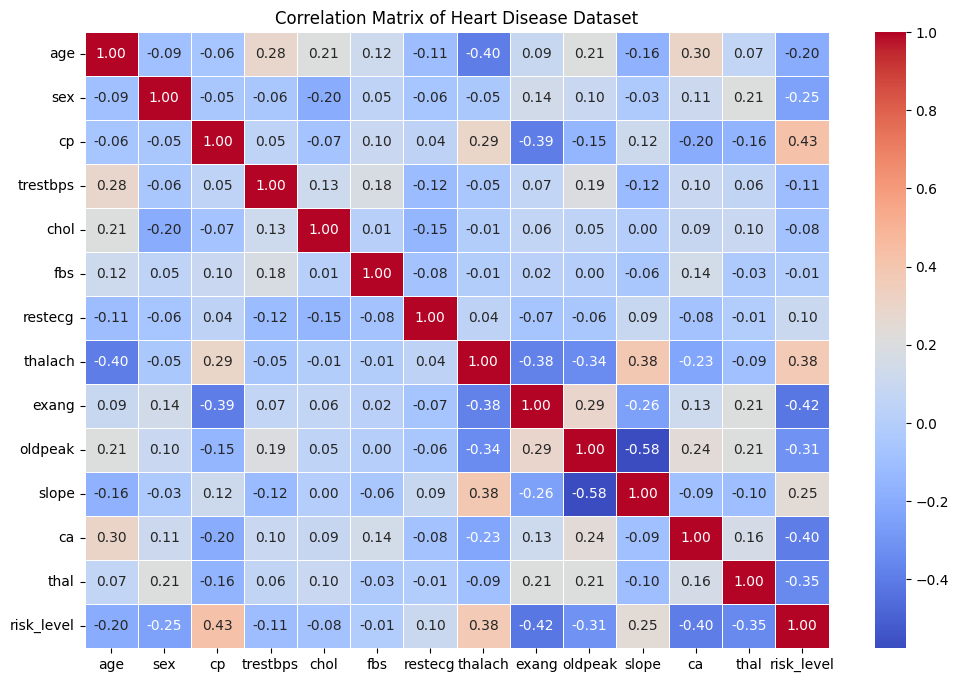

In [ ]:
corr_matrix = data.corr()
print(corr_matrix)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Heart Disease Dataset")
plt.show()


In [41]:
# (80,20) split ratio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

report = classification_report(y_test, y_pred, output_dict=True)
precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Random forest results for 80:20 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Random forest results for 80:20 split ratio:
Accuracy: 0.85
Precision (Weighted): 0.86
Recall (Weighted): 0.85
F1 Score (Weighted): 0.85


In [33]:
# (70,30) split ratio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Random forest results for 70:30 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Random forest results for 70:30 split ratio:
Accuracy: 0.79
Precision (Weighted): 0.79
Recall (Weighted): 0.79
F1 Score (Weighted): 0.79


In [40]:
# (75,25) split ratio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Random forest results for 75:25 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Random forest results for 75:25 split ratio:
Accuracy: 0.84
Precision (Weighted): 0.84
Recall (Weighted): 0.84
F1 Score (Weighted): 0.84


In [37]:
#split(80,20)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = OneVsRestClassifier(
    LogisticRegression(solver="lbfgs", max_iter=2000, C=1.5, random_state=42)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Logistic Regression results for 80:20 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Logistic Regression results for 80:20 split ratio:
Accuracy: 0.82
Precision (Weighted): 0.86
Recall (Weighted): 0.82
F1 Score (Weighted): 0.83


In [38]:
#split(70,30)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = OneVsRestClassifier(
    LogisticRegression(solver="lbfgs", max_iter=2000, C=1.5, random_state=42)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Logistic Regression results for 70:30 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Logistic Regression results for 70:30 split ratio:
Accuracy: 0.75
Precision (Weighted): 0.79
Recall (Weighted): 0.75
F1 Score (Weighted): 0.76


In [39]:
#Split(75,25)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

selected_features = ["cp", "thalach", "oldpeak", "exang", "ca", "thal"]
X = data[selected_features]
y = data["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = OneVsRestClassifier(
    LogisticRegression(solver="lbfgs", max_iter=2000, C=1.5, random_state=42)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']

print("Logistic Regression results for 75:25 split ratio:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")


Logistic Regression results for 75:25 split ratio:
Accuracy: 0.79
Precision (Weighted): 0.84
Recall (Weighted): 0.79
F1 Score (Weighted): 0.81
